# Clearn code

In [2]:
# from rdkit.Chem import PandasTools
import numpy as np
import pandas as pd
# from rdkit import DataStructs
# from rdkit.Chem import AllChem as Chem
# from rdkit.Chem import Draw
# from rdkit.Chem import Descriptors
# from rdkit.ML.Descriptors import MoleculeDescriptors
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle
import random
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import LeaveOneOut
from sklearn import preprocessing
#from genetic_selection import GeneticSelectionCV
# from mordred import Calculator, descriptors
import pickle 
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Data loading 

In [11]:
import os
os.getcwd()

'/mnt/d/Programming/ChemDray_story/ChemDraw/ChemDraw/code'

In [ ]:
data = pd.read_csv("../data/allData.csv")# исходные данные 

# Чтение сохранённых фич 
with open('../code/streamlit/features_a2.pkl', 'rb') as file:
    features_a = pickle.load(file)
with open('../code/streamlit/features_b2.pkl', 'rb') as file:
    features_b = pickle.load(file)

In [7]:
data = data.loc[:, (data != 0).any(axis=0)] # Удалим все столбцы с нулями 

df_no_zeroB = data[data['b'] != 0]
df_no_zeroB = df_no_zeroB.reset_index()
df_no_zeroB= df_no_zeroB[df_no_zeroB.columns[1:]]

In [10]:
data.head(4)

,inp+inp=out,a,b,reagent1_nBase,reagent1_SpAbs_A,reagent1_SpMax_A,reagent1_SpDiam_A,reagent1_SpAD_A,reagent1_SpMAD_A,reagent1_LogEE_A,...,product1_SRW10,product1_TSRW10,product1_MW,product1_AMW,product1_WPath,product1_WPol,product1_Zagreb1,product1_Zagreb2,product1_mZagreb1,product1_mZagreb2
0,1a+2a=3aa,14,36,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,8.985821,45.252219,228.227328,4.855901,456.0,18.0,60.0,64.0,6.562500,4.000000
1,1a+2b=3ab,53,55,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,9.325899,48.607448,248.196027,5.515467,632.0,20.0,76.0,82.0,6.173611,4.041667
2,1a+2c=3ac,67,58,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,9.817766,55.491378,310.211677,5.965609,1143.0,31.0,104.0,118.0,6.534722,5.208333
3,1a+2d=3ad,89,96,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,10.167735,61.874837,372.227328,6.308938,1794.0,42.0,132.0,154.0,6.895833,6.375000


In [ ]:
df_no_zeroB.head(4) # тут нет строк с b = 0

,inp+inp=out,a,b,reagent1_nBase,reagent1_SpAbs_A,reagent1_SpMax_A,reagent1_SpDiam_A,reagent1_SpAD_A,reagent1_SpMAD_A,reagent1_LogEE_A,...,product1_SRW10,product1_TSRW10,product1_MW,product1_AMW,product1_WPath,product1_WPol,product1_Zagreb1,product1_Zagreb2,product1_mZagreb1,product1_mZagreb2
0,1a+2a=3aa,14,36,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,8.985821,45.252219,228.227328,4.855901,456.0,18.0,60.0,64.0,6.562500,4.000000
1,1a+2b=3ab,53,55,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,9.325899,48.607448,248.196027,5.515467,632.0,20.0,76.0,82.0,6.173611,4.041667
2,1a+2c=3ac,67,58,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,9.817766,55.491378,310.211677,5.965609,1143.0,31.0,104.0,118.0,6.534722,5.208333
3,1a+2d=3ad,89,96,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,10.167735,61.874837,372.227328,6.308938,1794.0,42.0,132.0,154.0,6.895833,6.375000


# Fit using ExstraTrees
### We use LOOCV + castom mixing 

In [12]:
def extra_trees_loo_analysis_castom(X, y, test_size=5, random_state=42, picture = False, show_numb = False):
    """
    Полный анализ Extra Trees с Leave-One-Out и предсказаниями на новых данных
    """
    print("=" * 80)
    print("ПОЛНЫЙ АНАЛИЗ EXTRA TREES С LEAVE-ONE-OUT")
    print("=" * 80)
    
    # 1. Разделение данных на train и полностью новые данные
    X_train, X_new, y_train, y_new = train_test_split(
        X, y, test_size=test_size, random_state=random_state, shuffle=False
    )
    
    print(f"Размер тренировочных данных: {X_train.shape}")
    print(f"Размер новых данных (модель никогда не видела): {X_new.shape}")
    # print(f"Новые образцы для предсказания: {list(X_new.index)}")

    # Для финильной модели эти парамтеры показались мне наиболее оптимальными 
    et_model = ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features=0.6,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )
    
    # 3. Leave-One-Out кросс-валидация на тренировочных данных
    print("\n" + "=" * 50)
    print("LEAVE-ONE-OUT КРОСС-ВАЛИДАЦИЯ")
    print("=" * 50)
    
    loo = LeaveOneOut()
    loo_scores = []
    loo_predictions = []
    loo_true_values = []
    
    for train_idx, test_idx in loo.split(X_train):
        # Разделение для текущего фолда
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]
        
        # Обучение и предсказание
        et_model.fit(X_train_fold, y_train_fold)
        y_pred_fold = et_model.predict(X_test_fold)
        
        # Сохранение результатов
        mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
        loo_scores.append(-mse_fold)  # neg MSE для консистентности
        loo_predictions.extend(y_pred_fold)
        loo_true_values.extend(y_test_fold)
    
    # 4. Финальное обучение на всех тренировочных данных
    print("\n" + "=" * 50)
    print("ФИНАЛЬНОЕ ОБУЧЕНИЕ МОДЕЛИ")
    print("=" * 50)
    
    et_model.fit(X_train, y_train)
    
    # 6. Предсказания на совершенно новых данных
    y_new_pred = et_model.predict(X_new)
    original_y_new_pred = y_new_pred.copy() # предсказали для hold out

    # Теперь положим неизвестные ранее даныне обратно в модель чтобы не терять точность на LOOCV

    # Для финильной модели эти парамтеры показались мне наиболее оптимальными 
    et_model_all = ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features=0.6,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )
    # 2. Объедините все данные для LOOCV
    X_all = pd.concat([X_train, X_new])
    y_all = pd.concat([y_train, y_new])

    # 3. Сделайте LOOCV на ВСЕХ данных
    loo_all = LeaveOneOut()
    loo_scores_all = []
    loo_predictions_all = []
    loo_true_values_all = []

    for train_idx, test_idx in loo_all.split(X_all):
        X_train_fold, X_test_fold = X_all.iloc[train_idx], X_all.iloc[test_idx]
        y_train_fold, y_test_fold = y_all.iloc[train_idx], y_all.iloc[test_idx]
        
        et_model_all.fit(X_train_fold, y_train_fold)
        y_pred_fold = et_model_all.predict(X_test_fold)
        
        mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
        loo_scores_all.append(-mse_fold)
        loo_predictions_all.extend(y_pred_fold)
        loo_true_values_all.extend(y_test_fold)

    from sklearn.base import clone

    et_model_loo = clone(et_model_all) # Делаем копию модели на LOOCV 
    et_model_all.fit(X_all, y_all) # Доучиваемся целиком 

    y_train_pred = et_model_all.predict(X_all) # Финальные предсказания 

    # 7. Вычисление метрик
    # На тренировочных данных
    train_r2 = r2_score(y_all, y_train_pred)
    train_mse = mean_squared_error(y_all, y_train_pred)
    train_mae = mean_absolute_error(y_all, y_train_pred)
    
    # LOO результаты, они полученны в результате самой кросс валидации 
    loo_r2 = r2_score(loo_true_values_all, loo_predictions_all)
    loo_mse = mean_squared_error(loo_true_values_all, loo_predictions_all)
    loo_mae = mean_absolute_error(loo_true_values_all, loo_predictions_all)
    
    # На новых данных
    new_r2 = r2_score(y_new, original_y_new_pred)
    new_mse = mean_squared_error(y_new, original_y_new_pred)
    new_mae = mean_absolute_error(y_new, original_y_new_pred)
    
    # 8. Вывод результатов
    print("\n📊 РЕЗУЛЬТАТЫ:")
    print("Метрики на тренировочных данных:")
    print(f"  R²: {train_r2:.4f}, MSE: {train_mse:.4f}, MAE: {train_mae:.4f}")
    
    print("\nМетрики Leave-One-Out:")
    print(f"  R²: {loo_r2:.4f}, MSE: {loo_mse:.4f}, MAE: {loo_mae:.4f}")
    print(f"  LOO Score (mean neg_MSE): {np.mean(loo_scores_all):.4f} ± {np.std(loo_scores_all):.4f}")
    
    print("\nМетрики на НОВЫХ данных (модель никогда не видела):")
    print(f"  R²: {new_r2:.4f}, MSE: {new_mse:.4f}, MAE: {new_mae:.4f}")
    
    if picture == True:
        # 9. Визуализация
        plot_comprehensive_analysis(
            y_all, y_train_pred, 
            loo_true_values_all, loo_predictions_all,
            y_new, original_y_new_pred,
            X_new.index, show_numb
        )
        
        # 10. Детальная информация о новых предсказаниях
        print_new_predictions_details(X_new, y_new, y_new_pred, X_new.index)
    return {
            'model': et_model_all,
            'LOOCV model': et_model_loo,
            'X_train': X_all,
            'y_train': y_all,
            'X_new': X_new,
            'y_new': y_new,
            'y_new_pred': y_new_pred,
            'loo_scores': loo_scores_all,
            'loo_predictions': loo_predictions_all,
            'loo_true_values': loo_true_values_all,
            'AE_LOOCV': np.abs((np.array(loo_true_values_all) - np.array(loo_predictions_all))),
            'AE_last': np.abs((np.array(y_all) - np.array(y_train_pred))),
            'metrics': {
                'train': {'r2': train_r2, 'mse': train_mse, 'mae': train_mae},
                'loo': {'r2': loo_r2, 'mse': loo_mse, 'mae': loo_mae},
                'new': {'r2': new_r2, 'mse': new_mse, 'mae': new_mae}
            }
    }
        
def plot_comprehensive_analysis(y_train, y_train_pred, loo_true, loo_pred, y_new, y_new_pred, new_indices, show_numb):
    """
    Комплексная визуализация результатов
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Comprehensive analysis of pretiction \n for "A" using features selected for "B"', fontsize=16, fontweight='bold')
    
    # 1. Parity Plot - тренировочные данные
    axes[0, 0].scatter(y_train, y_train_pred, alpha=0.6, color='blue', s=50)
    if show_numb == True:
        for i, idx in enumerate(y_train):
            axes[0, 0].annotate(f'{i}', (y_train[i], y_train_pred[i]), 
                            xytext=(5, 5), textcoords='offset points', fontsize=8)
    min_val = min(y_train.min(), y_train_pred.min())
    max_val = max(y_train.max(), y_train_pred.max())
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[0, 0].set_xlabel('True Values')
    axes[0, 0].set_ylabel('Predicted Values')
    axes[0, 0].set_title('Parity Plot: predictions for training on all data after LOOCV')
    axes[0, 0].grid(True, alpha=0.3)
    r2_train = r2_score(y_train, y_train_pred)
    axes[0, 0].text(0.05, 0.95, f'R² = {r2_train:.3f}', transform=axes[0, 0].transAxes,
                   bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # 2. Parity Plot - LOO
    axes[0, 1].scatter(loo_true, loo_pred, alpha=0.6, color='green', s=50)
    if show_numb == True:
        for i, idx in enumerate(loo_true):
            axes[0, 1].annotate(f'{i}', (loo_true[i], loo_pred[i]), 
                            xytext=(5, 5), textcoords='offset points', fontsize=8)
    min_val_loo = min(min(loo_true), min(loo_pred))
    max_val_loo = max(max(loo_true), max(loo_pred))
    axes[0, 1].plot([min_val_loo, max_val_loo], [min_val_loo, max_val_loo], 'r--', linewidth=2)
    axes[0, 1].set_xlabel('True Values')
    axes[0, 1].set_ylabel('Predicted Values')
    axes[0, 1].set_title('Parity Plot: predictions for Leave-One-Out cross-validation (LOOCV)')
    axes[0, 1].grid(True, alpha=0.3)
    r2_loo = r2_score(loo_true, loo_pred)
    axes[0, 1].text(0.05, 0.95, f'R² = {r2_loo:.3f}', transform=axes[0, 1].transAxes,
                   bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # 3. Parity Plot - Новые для модели данные
    axes[0, 2].scatter(y_new, y_new_pred, alpha=0.6, color='red', s=80, edgecolors='black')
    if show_numb == True:
        for i, idx in enumerate(new_indices):
            axes[0, 2].annotate(f'{idx}', (y_new.iloc[i], y_new_pred[i]), 
                            xytext=(5, 5), textcoords='offset points', fontsize=8)
    min_val_new = min(min(y_new), min(y_new_pred))
    max_val_new = max(max(y_new), max(y_new_pred))
    axes[0, 2].plot([min_val_new, max_val_new], [min_val_new, max_val_new], 'r--', linewidth=2)
    axes[0, 2].set_xlabel('True Values')
    axes[0, 2].set_ylabel('Predicted Values')
    axes[0, 2].set_title('Parity Plot: predictions for hold out sample')
    axes[0, 2].grid(True, alpha=0.3)
    r2_new = r2_score(y_new, y_new_pred)
    axes[0, 2].text(0.05, 0.95, f'R² = {r2_new:.3f}', transform=axes[0, 2].transAxes,
                   bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # 4. Распределение остатков - Train
    residuals_train = y_train - y_train_pred
    axes[1, 0].hist(residuals_train, bins=15, alpha=0.7, color='blue', edgecolor='black')
    axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Residuals')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of prediction errors \n in training on all data after LOOCV')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].text(0.05, 0.95, f'Mean value: {residuals_train.mean():.3f}\nStandard deviation: {residuals_train.std():.3f}', 
                   transform=axes[1, 0].transAxes, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # 5. Распределение остатков - LOO
    residuals_loo = np.array(loo_true) - np.array(loo_pred)
    axes[1, 1].hist(residuals_loo, bins=15, alpha=0.7, color='green', edgecolor='black')
    axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('Residuals')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Residuals distribution errors for \n Leave-One-Out cross-validation (LOOCV)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].text(0.05, 0.95, f'Mean value: {residuals_loo.mean():.3f}\nStandard deviation: {residuals_loo.std():.3f}', 
                   transform=axes[1, 1].transAxes, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # 6. Распределение остатков - Новые данные
    residuals_new = y_new - y_new_pred
    axes[1, 2].hist(residuals_new, bins=min(10, len(y_new)), alpha=0.7, color='red', edgecolor='black')
    axes[1, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 2].set_xlabel('Residuals')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_title('Residuals Distribution errors for hold out sample')
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].text(0.05, 0.95, f'Mean value: {residuals_new.mean():.3f}\nStandard deviation: {residuals_new.std():.3f}', 
                   transform=axes[1, 2].transAxes, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def print_new_predictions_details(X_new, y_new, y_new_pred, indices):
    """
    Детальная информация о предсказаниях на новых данных
    """
    print("\n" + "=" * 80)
    print("ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ПРЕДСКАЗАНИЯХ НА НОВЫХ ДАННЫХ")
    print("=" * 80)
    
    predictions_df = pd.DataFrame({
        'Образец': indices,
        'Истинное значение': y_new.values,
        'Предсказанное значение': y_new_pred,
        'Ошибка': y_new.values - y_new_pred,
        'Абсолютная ошибка': np.abs(y_new.values - y_new_pred),
        'Относительная ошибка (%)': np.abs((y_new.values - y_new_pred) / y_new.values) * 100
    })
    
    print(predictions_df.round(4))
    
    print(f"\n📈 СТАТИСТИКА ОШИБОК НА НОВЫХ ДАННЫХ:")
    print(f"  Средняя абсолютная ошибка: {predictions_df['Абсолютная ошибка'].mean():.4f}")
    print(f"  Максимальная абсолютная ошибка: {predictions_df['Абсолютная ошибка'].max():.4f}")
    print(f"  Средняя относительная ошибка: {predictions_df['Относительная ошибка (%)'].mean():.2f}%")
    print(f"  Стандартное отклонение ошибок: {predictions_df['Ошибка'].std():.4f}")


# Models

Запуск комплексного анализа Extra Trees...
ПОЛНЫЙ АНАЛИЗ EXTRA TREES С LEAVE-ONE-OUT
Размер тренировочных данных: (43, 25)
Размер новых данных (модель никогда не видела): (10, 25)

LEAVE-ONE-OUT КРОСС-ВАЛИДАЦИЯ

ФИНАЛЬНОЕ ОБУЧЕНИЕ МОДЕЛИ

📊 РЕЗУЛЬТАТЫ:
Метрики на тренировочных данных:
  R²: 0.9787, MSE: 12.6988, MAE: 2.7523

Метрики Leave-One-Out:
  R²: 0.7227, MSE: 164.9578, MAE: 10.8635
  LOO Score (mean neg_MSE): -164.9578 ± 193.7178

Метрики на НОВЫХ данных (модель никогда не видела):
  R²: 0.7168, MSE: 118.9661, MAE: 9.5085


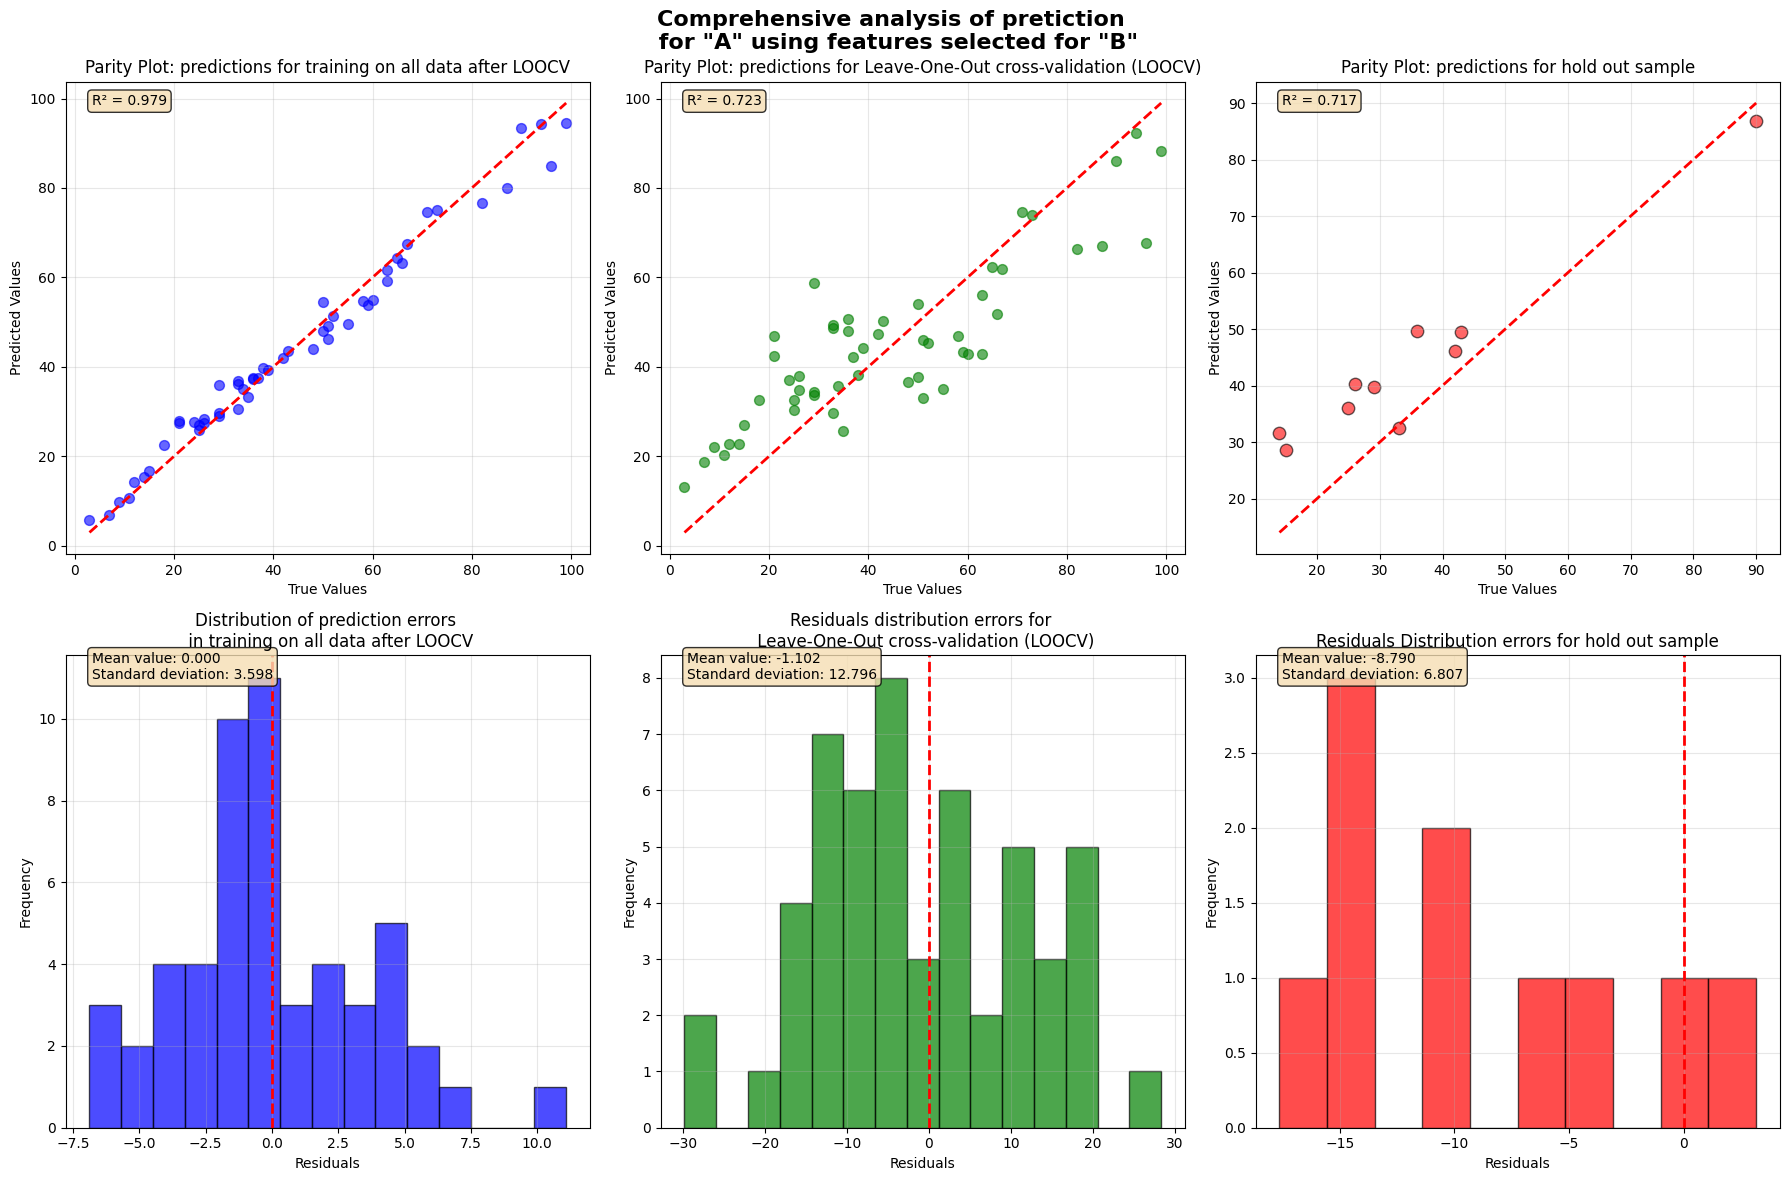


ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ПРЕДСКАЗАНИЯХ НА НОВЫХ ДАННЫХ
   Образец  Истинное значение  Предсказанное значение   Ошибка  \
0       43                 14                 31.6289 -17.6289   
1       44                 26                 40.2378 -14.2378   
2       45                 43                 49.5181  -6.5181   
3       46                 15                 28.5806 -13.5806   
4       47                 33                 32.5672   0.4328   
5       48                 42                 46.1872  -4.1872   
6       49                 25                 35.9456 -10.9456   
7       50                 29                 39.7481 -10.7481   
8       51                 36                 49.6463 -13.6463   
9       52                 90                 86.8403   3.1597   

   Абсолютная ошибка  Относительная ошибка (%)  
0            17.6289                  125.9206  
1            14.2378                   54.7607  
2             6.5181                   15.1583  
3            13.5806   

In [13]:
# ЗАПУСК АНАЛИЗА ДЛЯ В
print("Запуск комплексного анализа Extra Trees...")
results_b = extra_trees_loo_analysis_castom(df_no_zeroB[features_b[:25]], df_no_zeroB["b"], test_size=10, random_state=42, picture=True)

Запуск комплексного анализа Extra Trees...
ПОЛНЫЙ АНАЛИЗ EXTRA TREES С LEAVE-ONE-OUT
Размер тренировочных данных: (59, 26)
Размер новых данных (модель никогда не видела): (10, 26)

LEAVE-ONE-OUT КРОСС-ВАЛИДАЦИЯ

ФИНАЛЬНОЕ ОБУЧЕНИЕ МОДЕЛИ

📊 РЕЗУЛЬТАТЫ:
Метрики на тренировочных данных:
  R²: 0.9708, MSE: 23.4408, MAE: 3.5167

Метрики Leave-One-Out:
  R²: 0.7213, MSE: 223.7585, MAE: 11.8119
  LOO Score (mean neg_MSE): -223.7585 ± 316.2371

Метрики на НОВЫХ данных (модель никогда не видела):
  R²: 0.7104, MSE: 205.2225, MAE: 12.3750


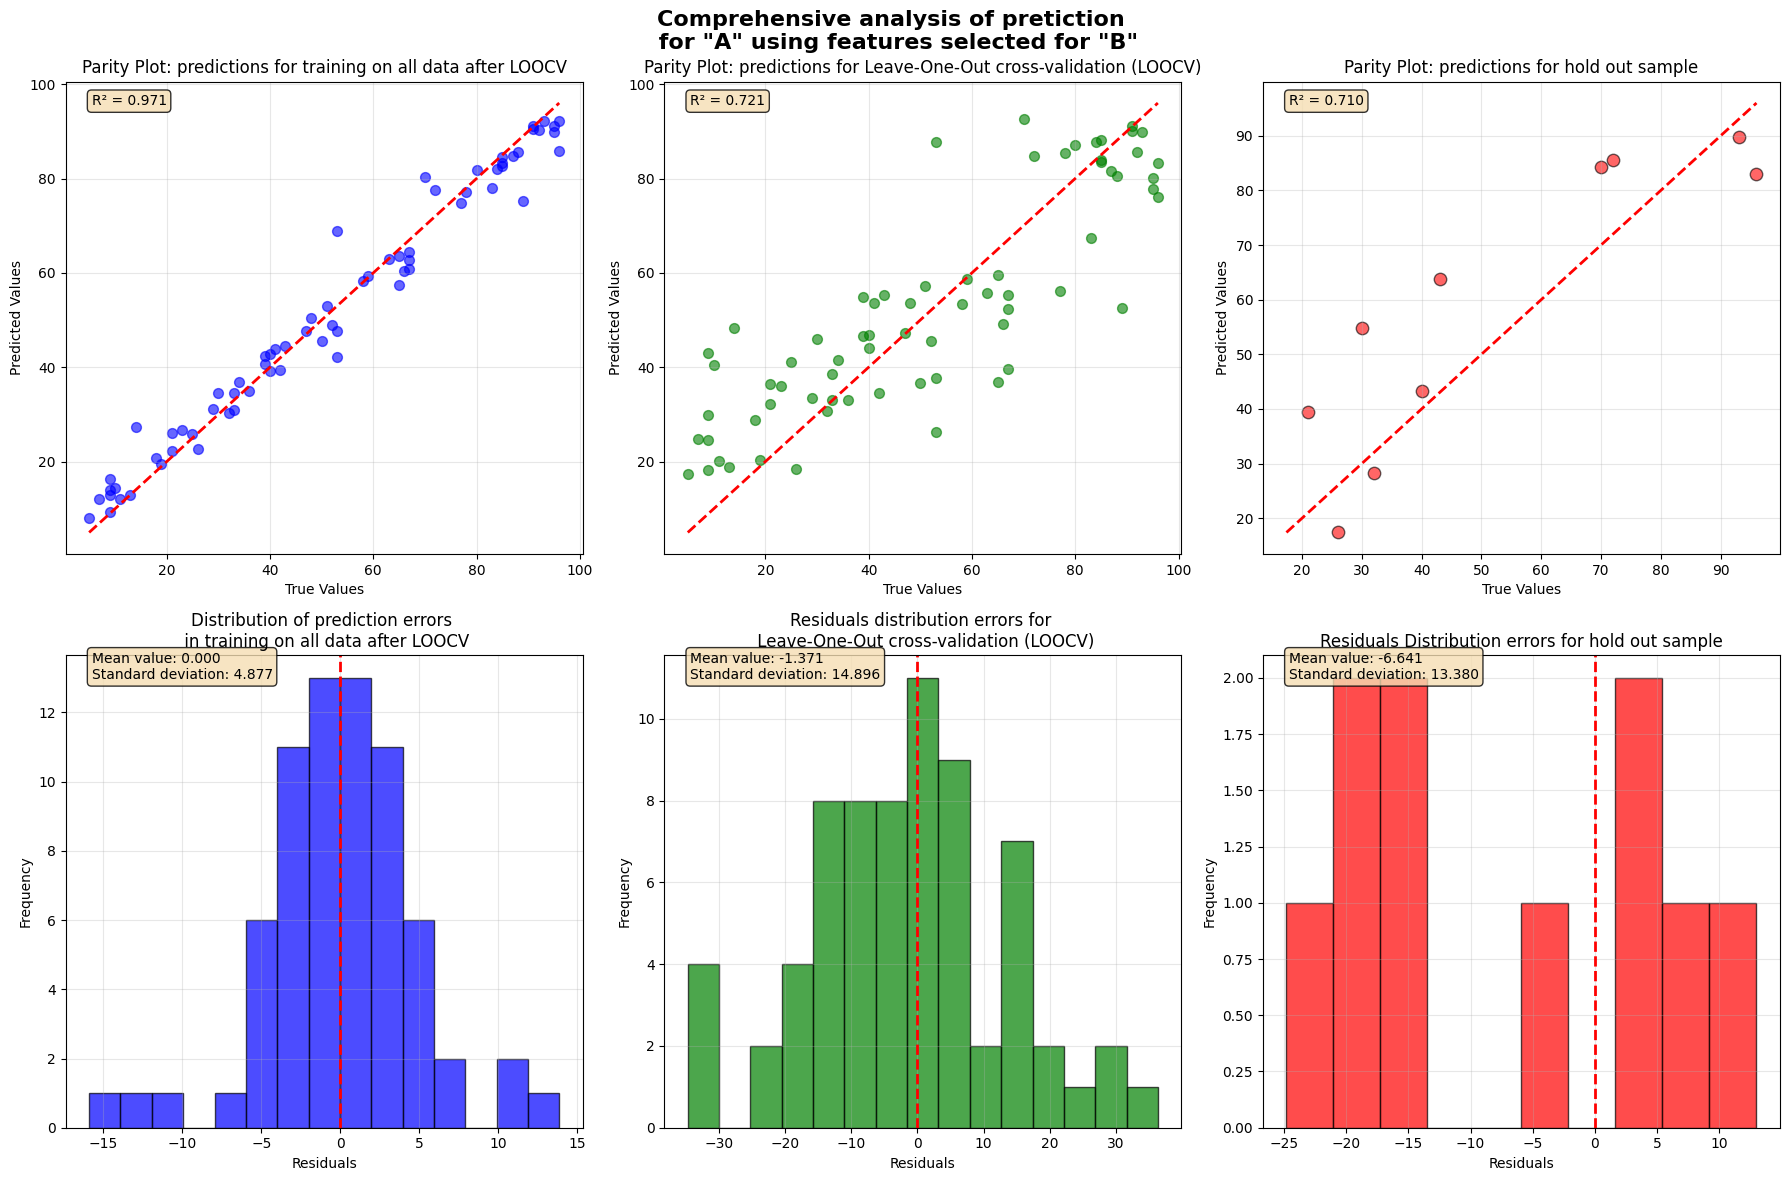


ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ПРЕДСКАЗАНИЯХ НА НОВЫХ ДАННЫХ
   Образец  Истинное значение  Предсказанное значение   Ошибка  \
0       59                 26                 17.3958   8.6042   
1       60                 32                 28.1950   3.8050   
2       61                 40                 43.2194  -3.2194   
3       62                 96                 83.0144  12.9856   
4       63                 21                 39.4900 -18.4900   
5       64                 30                 54.7973 -24.7973   
6       65                 43                 63.7056 -20.7056   
7       66                 72                 85.6306 -13.6306   
8       67                 93                 89.7248   3.2752   
9       68                 70                 84.2372 -14.2372   

   Абсолютная ошибка  Относительная ошибка (%)  
0             8.6042                   33.0929  
1             3.8050                   11.8906  
2             3.2194                    8.0486  
3            12.9856   

In [14]:
# ЗАПУСК АНАЛИЗА ДЛЯ А
print("Запуск комплексного анализа Extra Trees...")
results_a = extra_trees_loo_analysis_castom(data[features_a[:26]], data["a"], test_size=10, random_state=42, picture=True)

# Revers festures
### Here we use festures given by genetic algo for b, but learn to predict a

Запуск комплексного анализа Extra Trees...
ПОЛНЫЙ АНАЛИЗ EXTRA TREES С LEAVE-ONE-OUT
Размер тренировочных данных: (59, 25)
Размер новых данных (модель никогда не видела): (10, 25)

LEAVE-ONE-OUT КРОСС-ВАЛИДАЦИЯ

ФИНАЛЬНОЕ ОБУЧЕНИЕ МОДЕЛИ

📊 РЕЗУЛЬТАТЫ:
Метрики на тренировочных данных:
  R²: 0.9739, MSE: 20.9258, MAE: 3.4262

Метрики Leave-One-Out:
  R²: 0.7134, MSE: 230.0625, MAE: 11.6845
  LOO Score (mean neg_MSE): -230.0625 ± 320.5500

Метрики на НОВЫХ данных (модель никогда не видела):
  R²: 0.8595, MSE: 99.5854, MAE: 8.3605


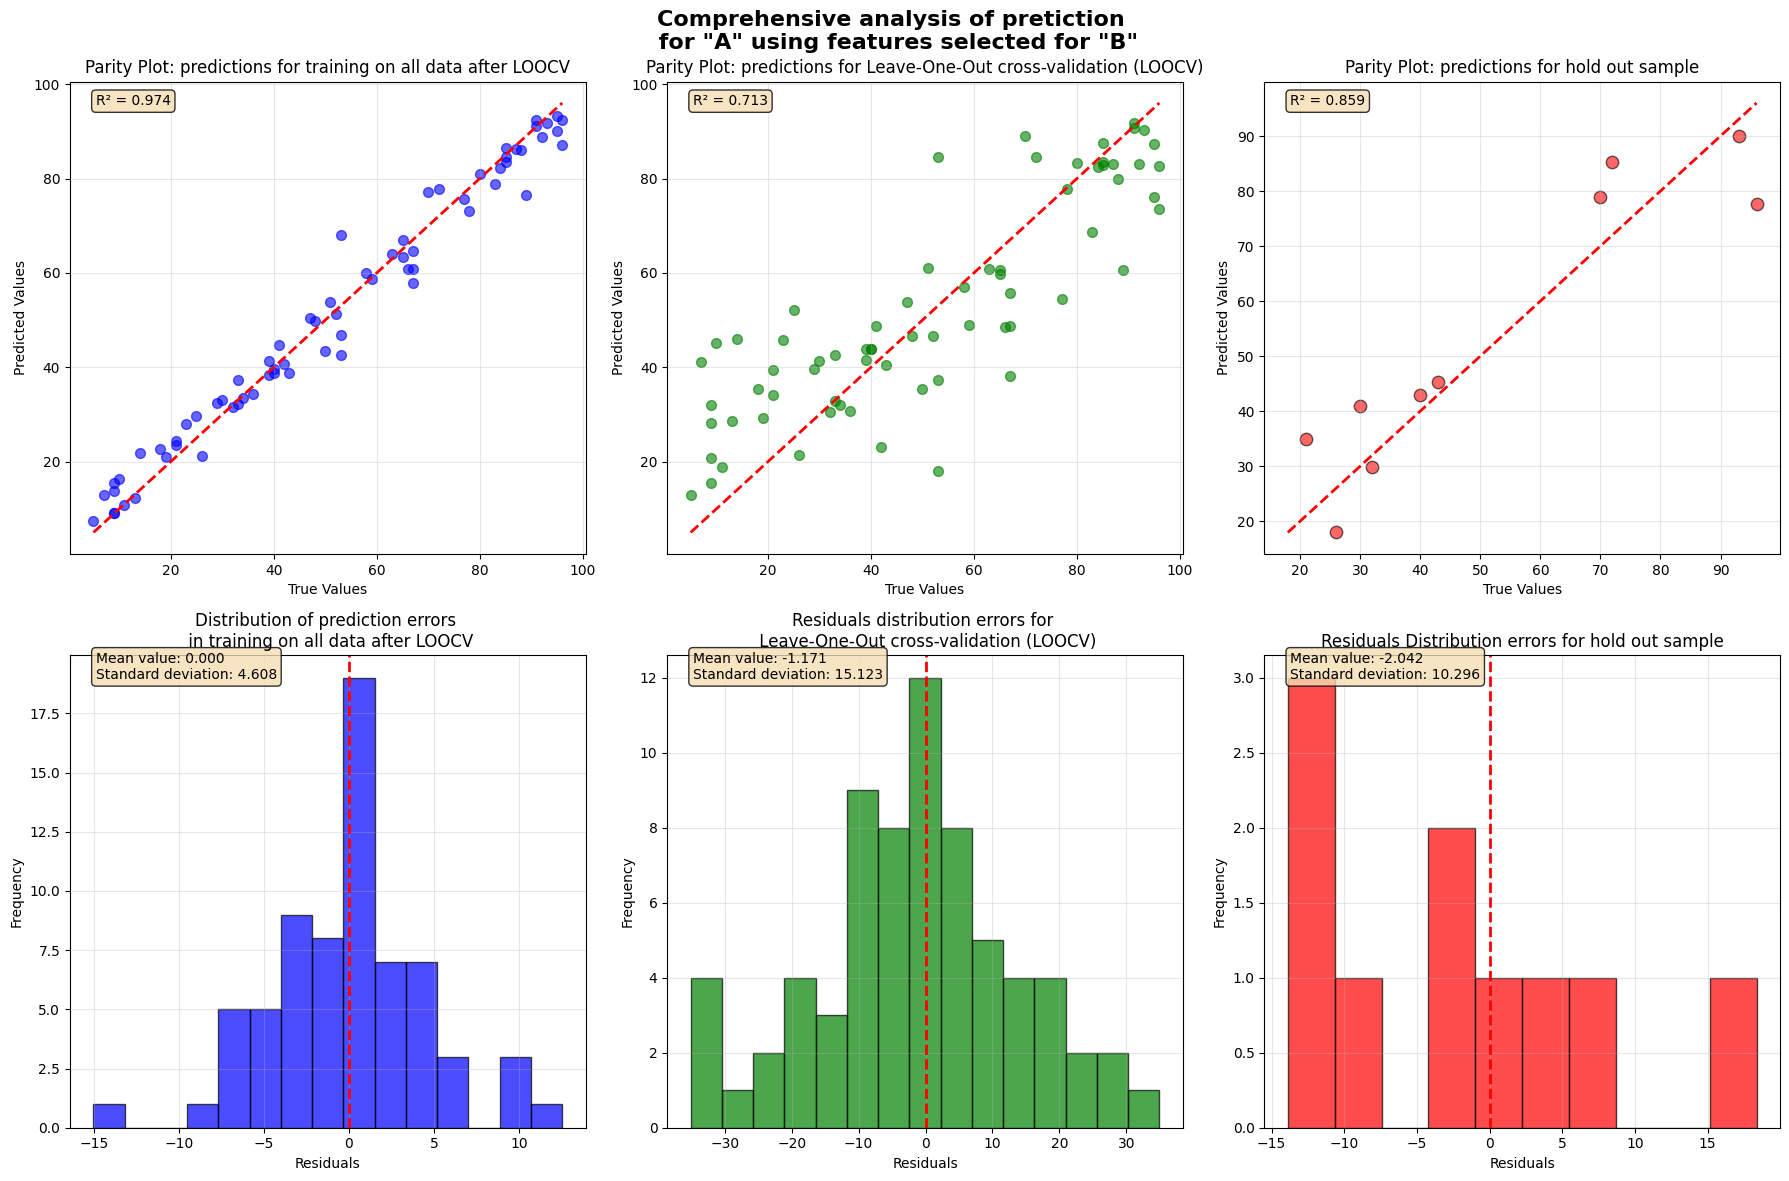


ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ПРЕДСКАЗАНИЯХ НА НОВЫХ ДАННЫХ
   Образец  Истинное значение  Предсказанное значение   Ошибка  \
0       59                 26                 17.9402   8.0598   
1       60                 32                 29.8507   2.1493   
2       61                 40                 42.8749  -2.8749   
3       62                 96                 77.6250  18.3750   
4       63                 21                 34.8789 -13.8789   
5       64                 30                 40.9071 -10.9071   
6       65                 43                 45.2058  -2.2058   
7       66                 72                 85.2675 -13.2675   
8       67                 93                 89.9928   3.0072   
9       68                 70                 78.8794  -8.8794   

   Абсолютная ошибка  Относительная ошибка (%)  
0             8.0598                   30.9994  
1             2.1493                    6.7165  
2             2.8749                    7.1872  
3            18.3750   

In [15]:
# ЗАПУСК АНАЛИЗА ДЛЯ В
print("Запуск комплексного анализа Extra Trees...")
resultsA_b = extra_trees_loo_analysis_castom(data[features_b[:25]], data["a"], test_size=10, random_state=42, picture=True)

# Saving models and features 

In [ ]:
# import joblib
# # Сохраняем модель, при том обученную 
# joblib.dump(results_a['model'], 'streamlit/model_a2.pkl')
# # Сохраняем массив фичей
# joblib.dump(features_a[:26], 'streamlit/features_a2.pkl')

# SHAP analys 

In [18]:
import shap

In [59]:
def shap_analysis_extra_trees(model, X, y=None, data = None, sample_size=100, random_state=42, rows_to_annotate = None, threshold = None, picture =True):
    """
    SHAP анализ для Extra Trees регрессии
    """
    print("=" * 80)
    print("SHAP ANALYSIS FOR EXTRA TREES REGRESSION")
    print("=" * 80)
    
    # Выбор подвыборки для ускорения вычислений
    if len(X) > sample_size:
        X_sample = X.sample(n=sample_size, random_state=random_state)
        print(f"Using sample of {sample_size} instances for SHAP analysis")
    else:
        X_sample = X
        print(f"Using all {len(X)} instances for SHAP analysis")
    
    # Инициализация SHAP объяснителя для деревьев
    explainer = shap.TreeExplainer(model)
    
    # Вычисление SHAP значений
    print("Calculating SHAP values...")
    shap_values = explainer.shap_values(X_sample)
    
    # Обработка expected_value для регрессии
    expected_value = explainer.expected_value
    if isinstance(expected_value, np.ndarray):
        expected_value = expected_value[0] if len(expected_value) > 0 else expected_value
    # print(f"Base value (expected value): {expected_value:.4f}")
    print(f"SHAP values shape: {shap_values.shape}")
    
    # Создание Explanation объекта для совместимости
    shap_explanation = shap.Explanation(
        values=shap_values,
        base_values=expected_value,
        data=X_sample.values,
        feature_names=X_sample.columns.tolist()
    )
    
    print("\n📈 Creating summary plot with index annotations...")
    plt.figure(figsize=(12, 8))
    
    # Создаем базовый summary plot
    shap.summary_plot(shap_values, X_sample, show=False)

    # Добавляем аннотации индексов для точек, превышающих threshold
    shap_df = _add_simple_index_annotations(shap_values, X_sample, df = data, threshold=threshold, rows_to_annotate= rows_to_annotate)
    
    plt.title(f"SHAP Summary Plot - Feature Importance", 
              fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # РАСЧЕТ ТОП-20 ПРИЗНАКОВ ПО СРЕДНЕМУ АБСОЛЮТНОМУ SHAP
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    feature_importance_df = pd.DataFrame({
        'feature': X_sample.columns,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)
    
    top_20_features = feature_importance_df.head(20)
    print("\n🔝 Top 20 most important features by mean |SHAP|:")
    print(top_20_features.to_string(index=False))
    
    if picture == True:
        # 2. Bar plot (средние абсолютные SHAP значения)
        print("📊 Creating feature importance plot...")
        plt.figure(figsize=(12, 6))
        shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
        plt.title("SHAP Feature Importance (Mean |SHAP|)", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # 3. Beeswarm plot
        print("🐝 Creating beeswarm plot...")
        plt.figure(figsize=(12, 8))
        shap.plots.beeswarm(shap_explanation, show=False)
        plt.title("SHAP Beeswarm Plot - Feature Effects", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # 4. Waterfall plot для первого наблюдения
        print("🌊 Creating waterfall plot for first instance...")
        plt.figure(figsize=(14, 8))
        shap.plots.waterfall(shap_explanation[0], show=False, max_display=15)
        plt.title(f"SHAP Waterfall Plot - Instance: {X_sample.index[0]}", 
                fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # 5. Force plot для первого наблюдения
        print("⚡ Creating force plot...")
        plt.figure(figsize=(14, 4))
        shap.plots.force(shap_explanation[0], matplotlib=True, show=False)
        plt.title(f"SHAP Force Plot - Instance: {X_sample.index[0]}", 
                fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # 6. Decision plot для нескольких наблюдений
        print("📈 Creating decision plot...")
        plt.figure(figsize=(14, 10))
        shap.decision_plot(expected_value, shap_values[:10], 
                        X_sample.iloc[:10], 
                        feature_names=list(X_sample.columns),
                        show=False)
        plt.title("SHAP Decision Plot (First 10 Instances)", 
                fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # # 7. Dependence plots для топ-4 признаков
        # print("📊 Creating dependence plots for top 4 features...")
        # top_features = get_top_features_from_shap(shap_values, X_sample.columns, n=4)
        
        # fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        # axes = axes.ravel()
        
        # for i, feature in enumerate(top_features):
        #     shap.dependence_plot(feature, shap_values, X_sample, 
        #                        ax=axes[i], show=False)
        #     axes[i].set_title(f'SHAP Dependence: {feature}', fontweight='bold', fontsize=12)
        #     axes[i].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
    # Возвращаем результаты
    results = {
        'shap_df':shap_df,
        'explainer': explainer,
        'shap_values': shap_values,
        'expected_value': expected_value,
        'X_sample': X_sample,
        'shap_explanation': shap_explanation,
        'top_20': top_20_features
    }
    
    return results

def _add_simple_index_annotations(shap_values, X_sample, df = None, threshold=None, rows_to_annotate = None):
    
    ax = plt.gca()
    print(f"Трешхолды:{threshold}")
    # Получаем порядок признаков с графика
    y_tick_labels = [label.get_text() for label in ax.get_yticklabels()]
    feature_names = X_sample.columns.tolist()

    threshold_dict = dict(zip(rows_to_annotate, threshold))

    position_to_feature_idx = {}
    print (y_tick_labels)
    print (rows_to_annotate)
    for position, feature_name in enumerate(y_tick_labels):
        if feature_name in rows_to_annotate:
            print(feature_name)
            position_to_feature_idx[position] = feature_names.index(feature_name)
    
    # Список для сбора информации о выбивающихся точках
    outlier_data = []

    # print(position_to_feature_idx)
    
    for position, feature_idx in position_to_feature_idx.items():
        feature_name = feature_names[feature_idx]
        feature_shap = shap_values[:, feature_idx]
        high_impact_indices = np.where(np.abs(feature_shap) > threshold_dict[X_sample.columns[feature_idx]])[0]
        
        # Группируем точки по x-координатам для этого признака
        x_positions = []
        for idx in high_impact_indices:
            shap_val = feature_shap[idx]
            sample_index = X_sample.index[idx]
            feature_value = X_sample.iloc[idx, feature_idx]
            
            # Сохраняем данные для вывода
            outlier_data.append({
                'feature': feature_name,
                'feature_value': feature_value,
                'index': sample_index,
                'reaction_name': df["inp+inp=out"][sample_index],
                'shap_value': shap_val,
                'abs_shap': abs(shap_val)
            })
            
            x_positions.append((shap_val, sample_index, position))
        
        # Сортируем по x координате
        x_positions.sort(key=lambda x: x[0])
        
        # Размещаем аннотации с разными y-смещениями
        for i, (x, text, y_pos) in enumerate(x_positions):
            # Чередуем смещения: выше, ниже, выше, ниже...
            y_offset = 10 if i % 2 == 0 else -10
            x_offset = 5 + (i % 3) * 8  # Разные x-смещения
            
            ax.annotate(text,
                       xy=(x, y_pos),
                       xytext=(x_offset, y_offset),
                       textcoords='offset points',
                       fontsize=6,
                       alpha=0.7,
                       bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.5))
    
    # Выводим таблицу с данными
    # _print_outlier_table_pandas(outlier_data, threshold)
    
    return outlier_data

In [60]:
rows_to_annotate = ["reagent2_GATS1p", "reagent1_ATSC7v", "reagent2_AATS1p", "reagent2_AATSC3p", "reagent2_TPSA", "reagent2_RPSA"]

SHAP ANALYSIS FOR EXTRA TREES REGRESSION
Using all 53 instances for SHAP analysis
Calculating SHAP values...
SHAP values shape: (53, 25)

📈 Creating summary plot with index annotations...
Трешхолды:[5, 4.5, 9, 9, 5, 5]
['reagent1_GATS2m', 'reagent1_AATSC5dv', 'reagent1_nC', 'reagent1_BCUTm-1h', 'reagent1_BCUTpe-1l', 'product1_MATS4m', 'reagent1_Mse', 'reagent2_RPSA', 'product1_AATS3s', 'reagent2_GGI5', 'product1_MATS7dv', 'reagent2_AATS1s', 'reagent2_TPSA', 'reagent2_AATSC3p', 'reagent2_AATS1p', 'reagent1_FPSA3', 'reagent1_ATSC7v', 'product1_AATSC4v', 'reagent2_GATS4se', 'reagent2_GATS1p']
['reagent2_GATS1p', 'reagent1_ATSC7v', 'reagent2_AATS1p', 'reagent2_AATSC3p', 'reagent2_TPSA', 'reagent2_RPSA']
reagent2_RPSA
reagent2_TPSA
reagent2_AATSC3p
reagent2_AATS1p
reagent1_ATSC7v
reagent2_GATS1p


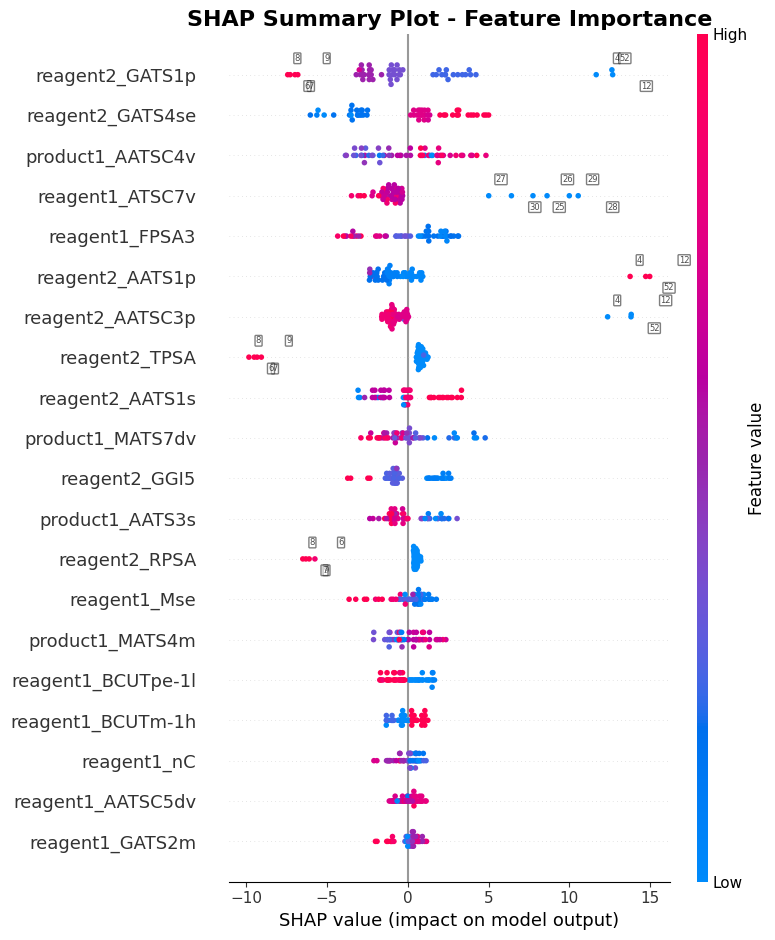


🔝 Top 20 most important features by mean |SHAP|:
           feature  mean_abs_shap
   reagent2_GATS1p       3.017674
  reagent2_GATS4se       2.653123
  product1_AATSC4v       2.047327
   reagent1_ATSC7v       1.963145
    reagent1_FPSA3       1.955343
   reagent2_AATS1p       1.874413
  reagent2_AATSC3p       1.497379
     reagent2_TPSA       1.472941
   reagent2_AATS1s       1.415763
  product1_MATS7dv       1.394571
     reagent2_GGI5       1.382396
   product1_AATS3s       1.113917
     reagent2_RPSA       0.945368
      reagent1_Mse       0.923961
   product1_MATS4m       0.891243
reagent1_BCUTpe-1l       0.884865
 reagent1_BCUTm-1h       0.624313
       reagent1_nC       0.587583
 reagent1_AATSC5dv       0.531546
   reagent1_GATS2m       0.521400
📊 Creating feature importance plot...


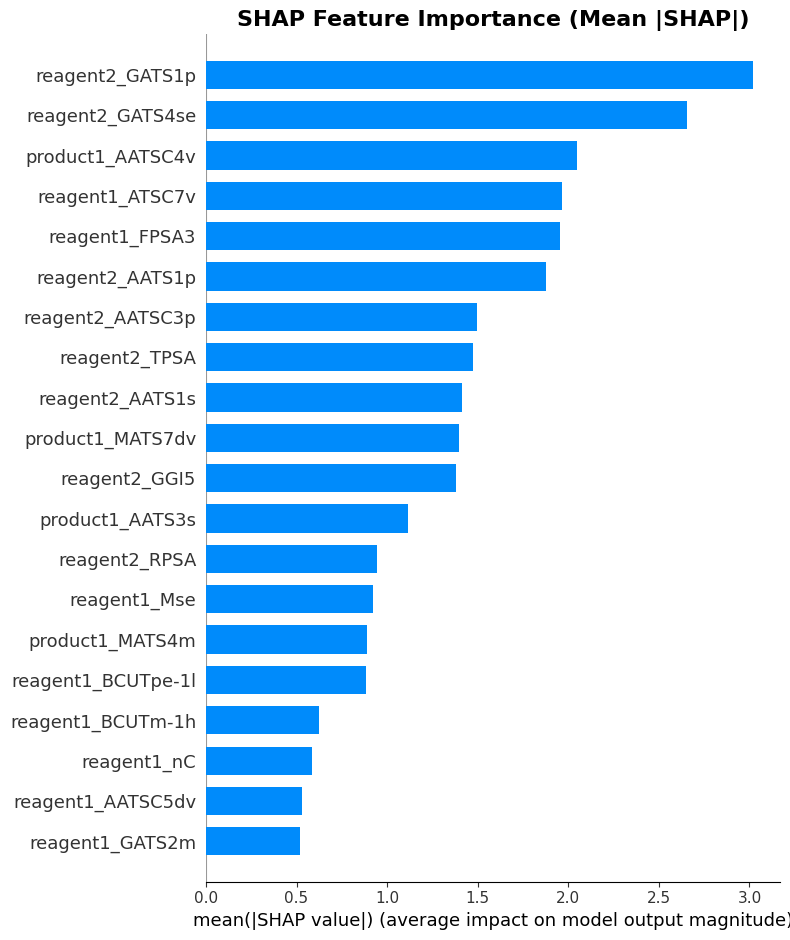

🐝 Creating beeswarm plot...


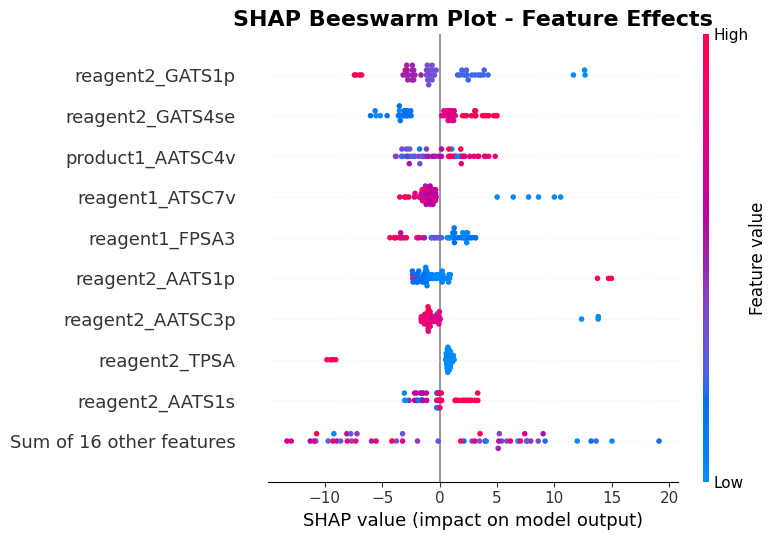

🌊 Creating waterfall plot for first instance...


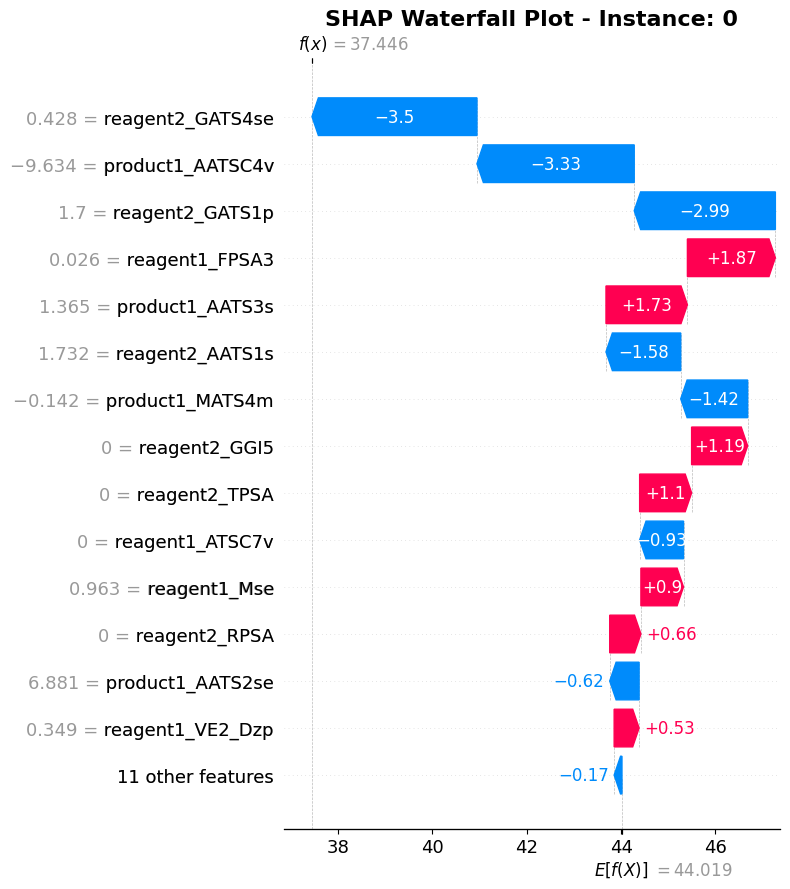

⚡ Creating force plot...


<Figure size 1400x400 with 0 Axes>

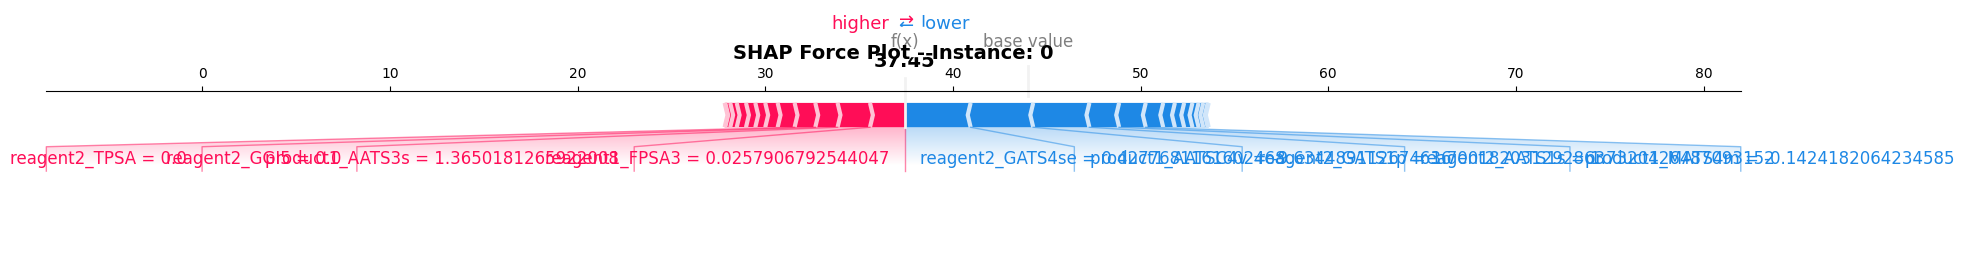

📈 Creating decision plot...


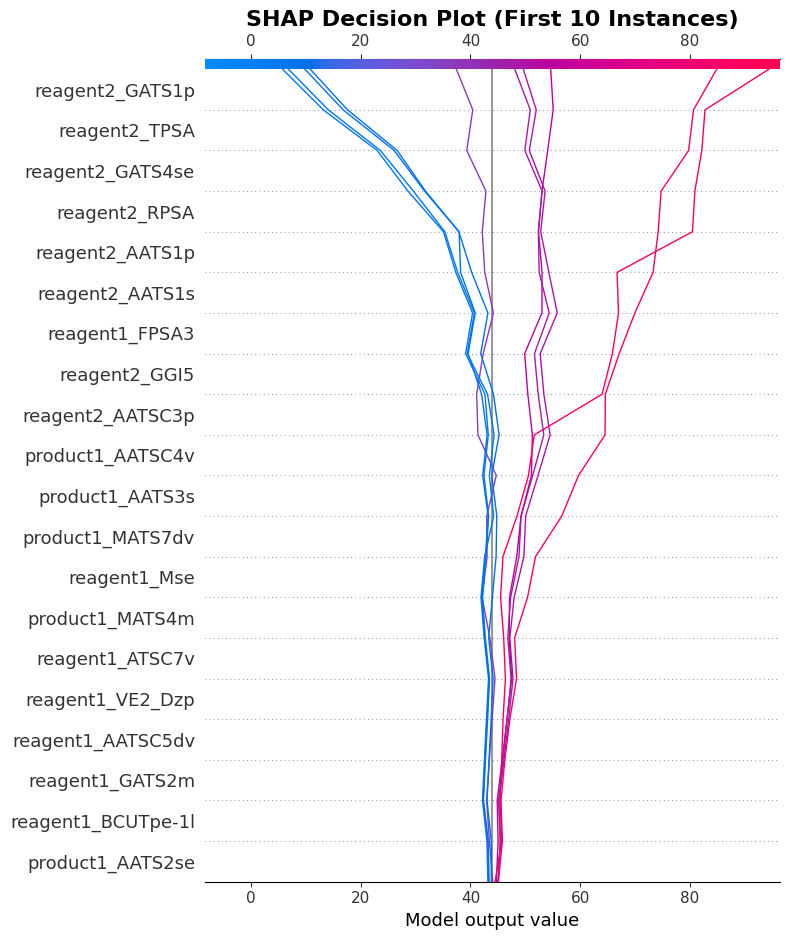

<Figure size 640x480 with 0 Axes>

In [61]:
# Расширенный анализ
# aut_SHAP_b = None
shap_resultsB = shap_analysis_extra_trees(
    model=results_b["model"], 
    X = df_no_zeroB[features_b[:25]], 
    data = df_no_zeroB, # DataFrame с исходными данными 
    y = df_no_zeroB["b"],
    rows_to_annotate = rows_to_annotate,  # На каких строках мы хотим видеть аннотации
    threshold = [5, 4.5, 9, 9, 5, 5]#[2] * len(rows_to_annotate)
    # threshold = 2.5 # Отсечка по значениям SHAP 
    )
# Создаем DataFrame
df_shap_b = pd.DataFrame(shap_resultsB['shap_df'])

In [66]:
b = shap_resultsB["top_20"]["feature"].to_list()

In [67]:
b

['reagent2_GATS1p',
 'reagent2_GATS4se',
 'product1_AATSC4v',
 'reagent1_ATSC7v',
 'reagent1_FPSA3',
 'reagent2_AATS1p',
 'reagent2_AATSC3p',
 'reagent2_TPSA',
 'reagent2_AATS1s',
 'product1_MATS7dv',
 'reagent2_GGI5',
 'product1_AATS3s',
 'reagent2_RPSA',
 'reagent1_Mse',
 'product1_MATS4m',
 'reagent1_BCUTpe-1l',
 'reagent1_BCUTm-1h',
 'reagent1_nC',
 'reagent1_AATSC5dv',
 'reagent1_GATS2m']

SHAP ANALYSIS FOR EXTRA TREES REGRESSION
Using all 69 instances for SHAP analysis
Calculating SHAP values...
SHAP values shape: (69, 26)

📈 Creating summary plot with index annotations...
Трешхолды:[5, 4.5, 9, 9, 5, 5]
['reagent1_SpMAD_Dzse', 'reagent1_ATS8m', 'reagent1_AATSC3i', 'reagent1_GATS2d', 'reagent1_AATSC0are', 'reagent1_GATS2i', 'reagent1_TASA', 'reagent2_SpAD_Dzse', 'reagent2_SRW04', 'reagent2_ATSC1se', 'product1_AATSC8m', 'product1_AATSC8p', 'product1_AATSC4m', 'product1_MATS8p', 'reagent1_C2SP2', 'product1_AATS3p', 'reagent2_MATS1se', 'reagent2_Mse', 'product1_ATSC1d', 'reagent2_MATS3v']
['reagent2_GATS1p', 'reagent1_ATSC7v', 'reagent2_AATS1p', 'reagent2_AATSC3p', 'reagent2_TPSA', 'reagent2_RPSA']


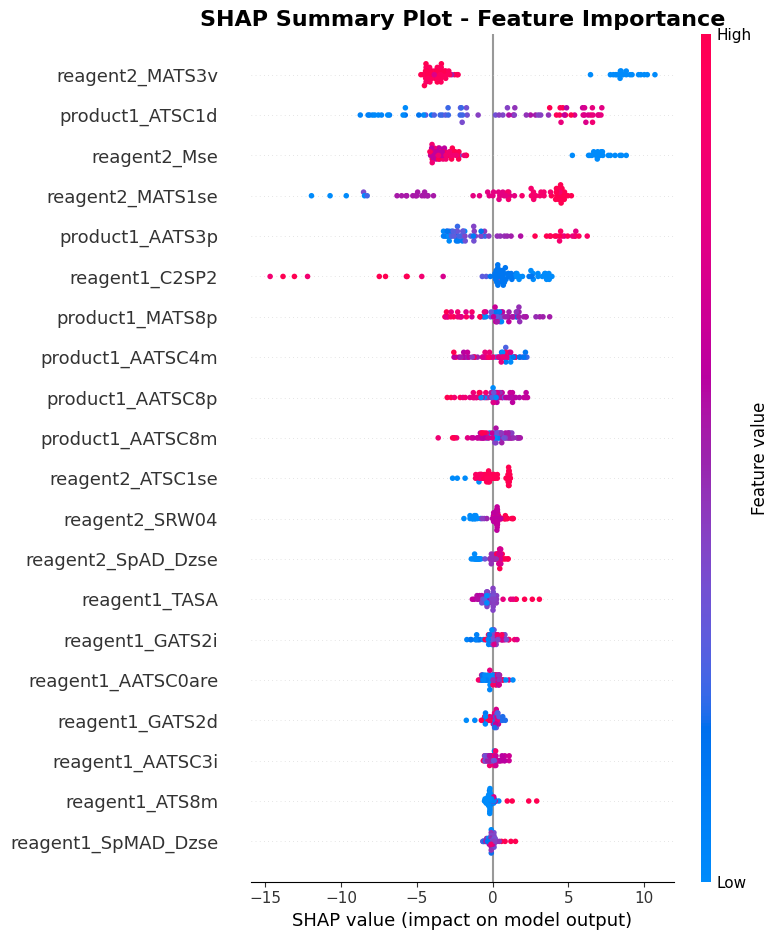


🔝 Top 20 most important features by mean |SHAP|:
            feature  mean_abs_shap
    reagent2_MATS3v       5.105419
    product1_ATSC1d       4.440248
       reagent2_Mse       4.299552
   reagent2_MATS1se       3.866256
    product1_AATS3p       2.638598
     reagent1_C2SP2       2.512964
    product1_MATS8p       1.365169
   product1_AATSC4m       1.148452
   product1_AATSC8p       0.933563
   product1_AATSC8m       0.893074
   reagent2_ATSC1se       0.718076
     reagent2_SRW04       0.623199
 reagent2_SpAD_Dzse       0.537767
      reagent1_TASA       0.515090
    reagent1_GATS2i       0.498066
 reagent1_AATSC0are       0.375732
    reagent1_GATS2d       0.355095
   reagent1_AATSC3i       0.316227
     reagent1_ATS8m       0.299837
reagent1_SpMAD_Dzse       0.230165
📊 Creating feature importance plot...


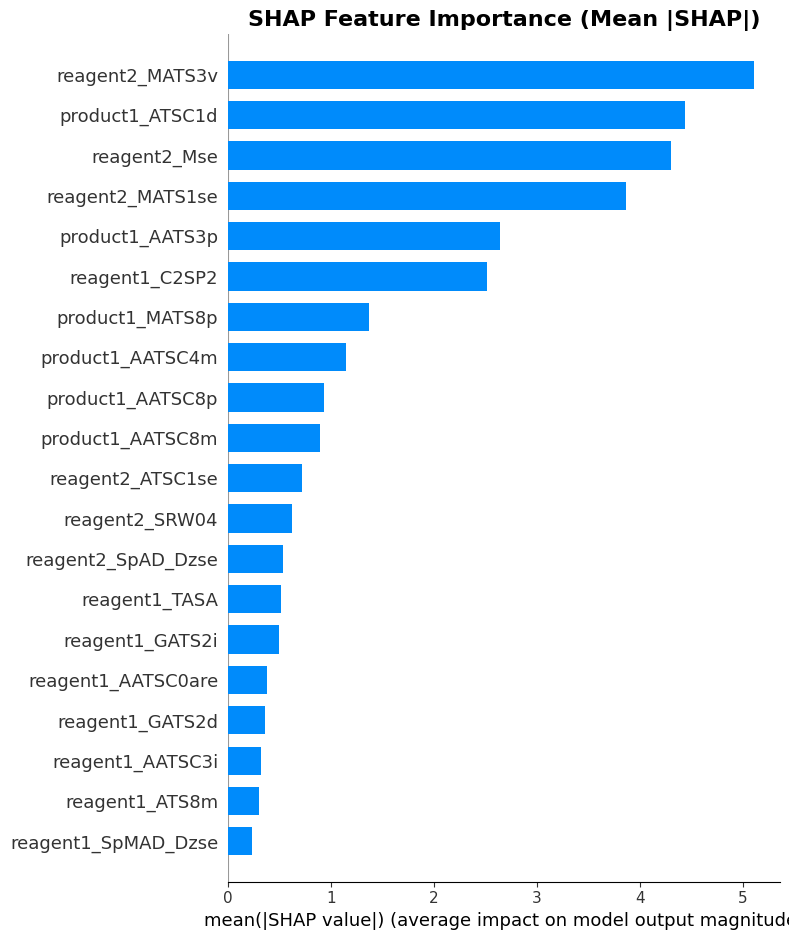

🐝 Creating beeswarm plot...


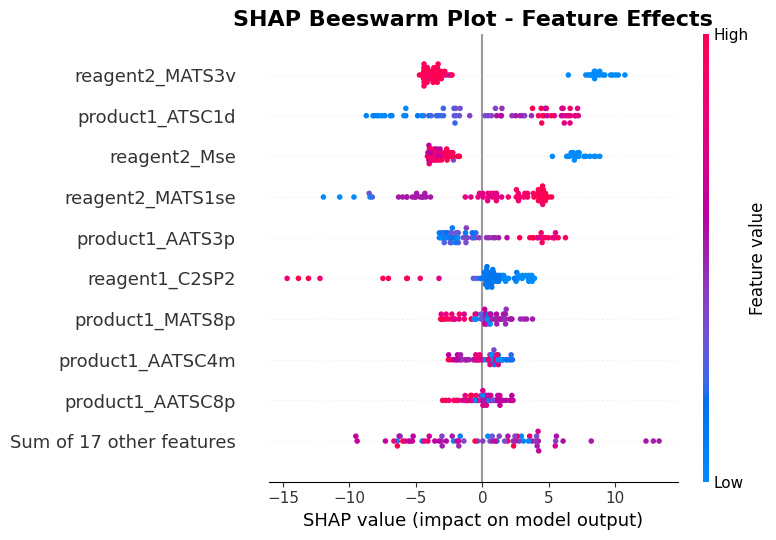

🌊 Creating waterfall plot for first instance...


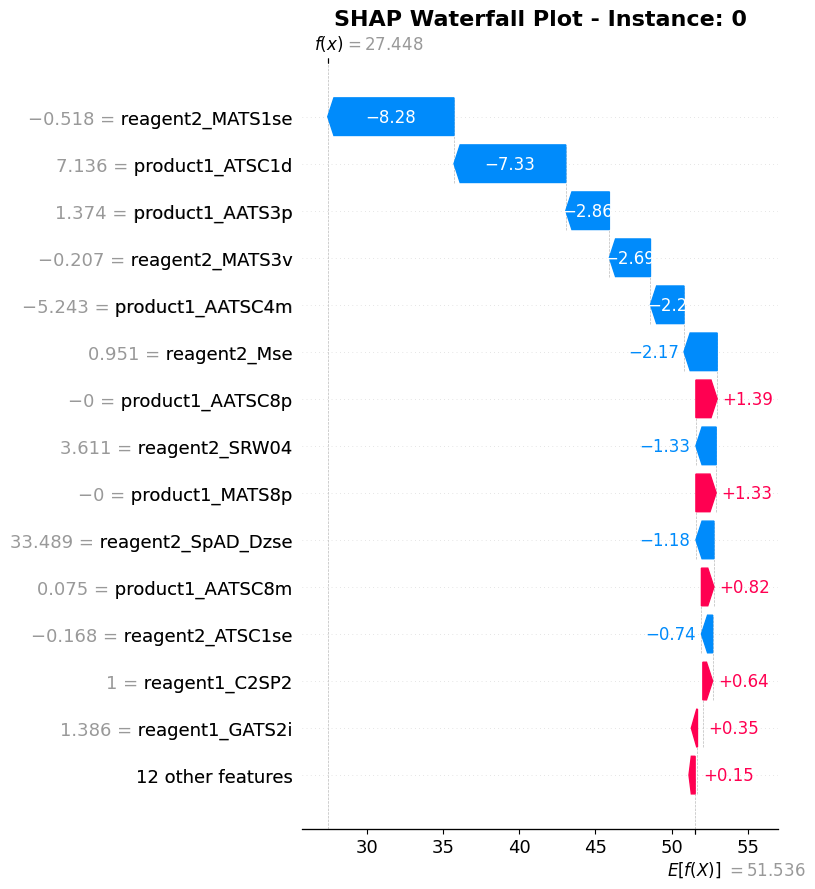

⚡ Creating force plot...


<Figure size 1400x400 with 0 Axes>

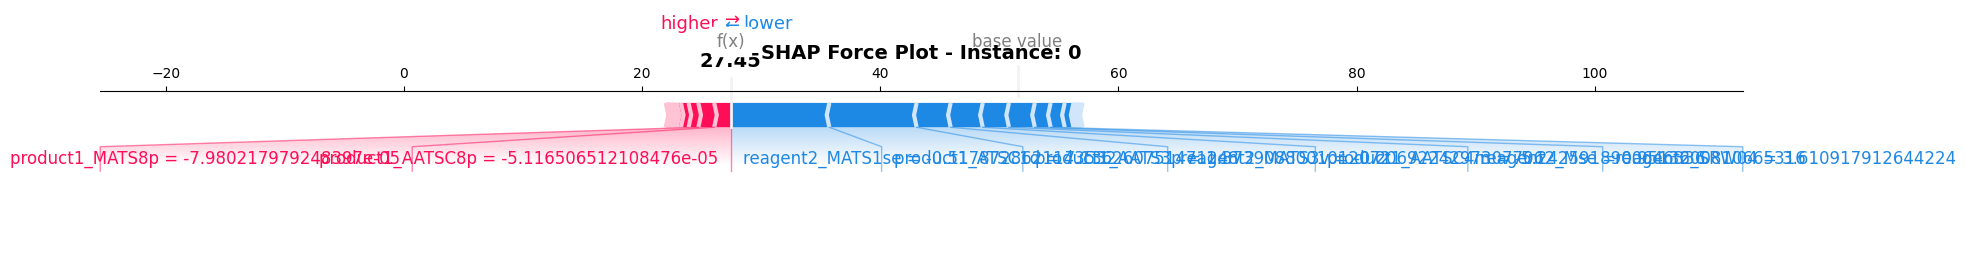

📈 Creating decision plot...


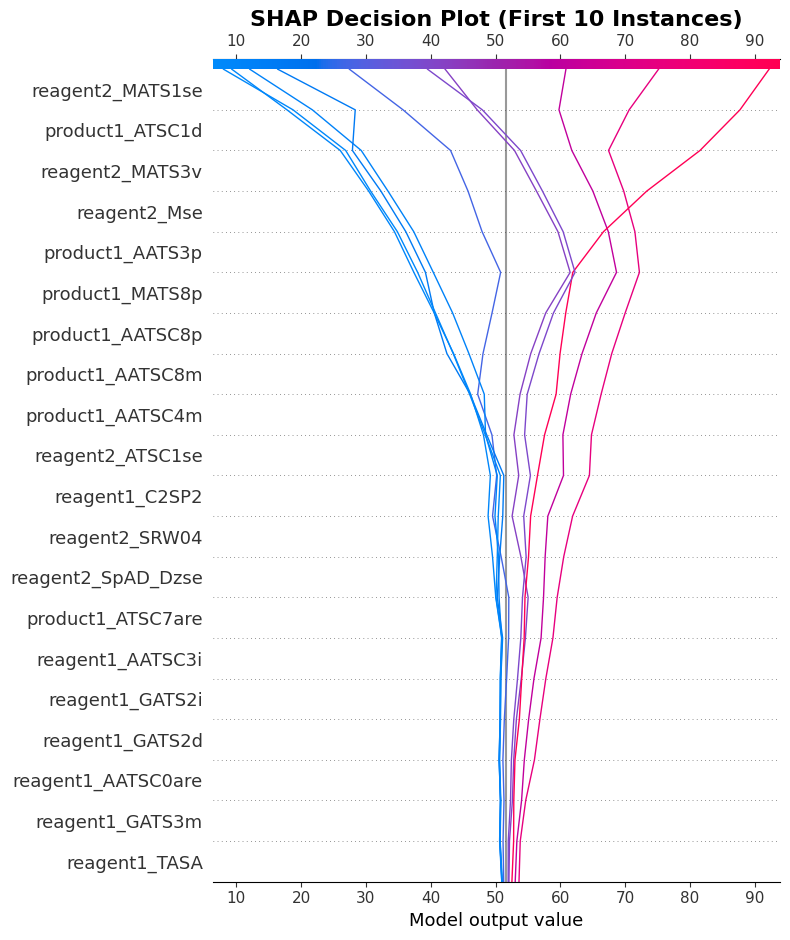

<Figure size 640x480 with 0 Axes>

In [68]:
shap_resultsA = shap_analysis_extra_trees(
    model=results_a["model"], 
    X = data[features_a[:26]], 
    data = data, # DataFrame с исходными данными 
    y = data["a"],
    rows_to_annotate = rows_to_annotate,  # На каких строках мы хотим видеть аннотации
    threshold = [5, 4.5, 9, 9, 5, 5]#[2] * len(rows_to_annotate)
    # threshold = 2.5 # Отсечка по значениям SHAP 
    )

In [70]:
a = shap_resultsA["top_20"]["feature"].to_list()

In [73]:
a

['reagent2_MATS3v',
 'product1_ATSC1d',
 'reagent2_Mse',
 'reagent2_MATS1se',
 'product1_AATS3p',
 'reagent1_C2SP2',
 'product1_MATS8p',
 'product1_AATSC4m',
 'product1_AATSC8p',
 'product1_AATSC8m',
 'reagent2_ATSC1se',
 'reagent2_SRW04',
 'reagent2_SpAD_Dzse',
 'reagent1_TASA',
 'reagent1_GATS2i',
 'reagent1_AATSC0are',
 'reagent1_GATS2d',
 'reagent1_AATSC3i',
 'reagent1_ATS8m',
 'reagent1_SpMAD_Dzse']

In [88]:
aa = ["A_" + i for i in a]

In [90]:
bb = ["B_" + i for i in b]

In [ ]:
len(aa+bb)

40

In [ ]:
m = aa+bb
o = a+b
for i in range(0, len(m)):
    data[m[i]] = data[o[i]]


In [94]:
df = pd.concat([data["inp+inp=out"],  data[m]], axis=1)

In [100]:
df

,inp+inp=out,A_reagent2_MATS3v,A_product1_ATSC1d,A_reagent2_Mse,A_reagent2_MATS1se,A_product1_AATS3p,A_reagent1_C2SP2,A_product1_MATS8p,A_product1_AATSC4m,A_product1_AATSC8p,...,B_reagent2_GGI5,B_product1_AATS3s,B_reagent2_RPSA,B_reagent1_Mse,B_product1_MATS4m,B_reagent1_BCUTpe-1l,B_reagent1_BCUTm-1h,B_reagent1_nC,B_reagent1_AATSC5dv,B_reagent1_GATS2m
0,1a+2a=3aa,-0.206922,7.136261,0.951360,-0.517873,1.373909,1.0,-0.000080,-5.242592,-0.000051,...,0.000000,1.365018,0.000000,0.962612,-0.142418,2.311713,12.251715,8.0,-1.518254e-17,1.386161
1,1a+2b=3ab,-0.099359,6.377778,0.957410,-0.326110,1.458821,1.0,-0.009920,-1.524733,-0.006621,...,0.125000,1.631146,0.000000,0.962612,-0.039133,2.311713,12.251715,8.0,-1.518254e-17,1.386161
2,1a+2c=3ac,-0.085619,10.443787,0.964052,-0.172638,1.663104,1.0,-0.010526,-3.014156,-0.006448,...,0.138889,1.696102,0.000000,0.962612,-0.078601,2.311713,12.251715,8.0,-1.518254e-17,1.386161
3,1a+2d=3ad,-0.098357,13.721632,0.968037,-0.100724,1.819321,1.0,-0.001478,-0.846217,-0.000842,...,0.041667,1.741417,0.000000,0.962612,-0.022502,2.311713,12.251715,8.0,-1.518254e-17,1.386161
4,1a+2e=3ae,-0.334065,19.253018,0.940099,-0.024336,2.625461,1.0,-0.011543,-13.709692,-0.016197,...,0.000000,1.325291,0.000000,0.962612,-0.244234,2.311713,12.251715,8.0,-1.518254e-17,1.386161
5,1a+2g=3ag,0.012221,5.342155,0.960120,-0.779331,1.381168,1.0,-0.015301,-2.286049,-0.012079,...,0.222222,1.628435,0.007319,0.962612,-0.054388,2.311713,12.251715,8.0,-1.518254e-17,1.386161
6,1a+2h=3ah,-0.086015,5.386445,0.963626,-0.872383,1.626183,1.0,0.085423,-0.668074,0.104073,...,0.500000,1.913822,0.034676,0.962612,-0.012305,2.311713,12.251715,8.0,-1.518254e-17,1.386161
7,1a+2i=3ai,-0.005603,13.655144,0.971005,-0.884948,1.903004,1.0,0.046289,6.352769,0.073011,...,2.611111,2.053873,0.024474,0.962612,0.097719,2.311713,12.251715,8.0,-1.518254e-17,1.386161
8,1a+2j=3aj,-0.152433,7.483564,0.966728,-0.877792,1.701518,1.0,0.133772,7.620015,0.180453,...,1.500000,1.952170,0.039696,0.962612,0.130794,2.311713,12.251715,8.0,-1.518254e-17,1.386161
9,1a+2k=3ak,-0.107701,7.483564,0.976651,-0.435681,1.701518,1.0,0.133772,7.620015,0.180453,...,0.500000,1.952170,0.038014,0.962612,0.130794,2.311713,12.251715,8.0,-1.518254e-17,1.386161


In [97]:
data.head()

,inp+inp=out,a,b,reagent1_nBase,reagent1_SpAbs_A,reagent1_SpMax_A,reagent1_SpDiam_A,reagent1_SpAD_A,reagent1_SpMAD_A,reagent1_LogEE_A,...,B_reagent2_GGI5,B_product1_AATS3s,B_reagent2_RPSA,B_reagent1_Mse,B_product1_MATS4m,B_reagent1_BCUTpe-1l,B_reagent1_BCUTm-1h,B_reagent1_nC,B_reagent1_AATSC5dv,B_reagent1_GATS2m
0,1a+2a=3aa,14,36,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,0.000000,1.365018,0.0,0.962612,-0.142418,2.311713,12.251715,8.0,-1.518254e-17,1.386161
1,1a+2b=3ab,53,55,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,0.125000,1.631146,0.0,0.962612,-0.039133,2.311713,12.251715,8.0,-1.518254e-17,1.386161
2,1a+2c=3ac,67,58,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,0.138889,1.696102,0.0,0.962612,-0.078601,2.311713,12.251715,8.0,-1.518254e-17,1.386161
3,1a+2d=3ad,89,96,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,0.041667,1.741417,0.0,0.962612,-0.022502,2.311713,12.251715,8.0,-1.518254e-17,1.386161
4,1a+2e=3ae,96,99,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,2.876615,...,0.000000,1.325291,0.0,0.962612,-0.244234,2.311713,12.251715,8.0,-1.518254e-17,1.386161


In [101]:
df.to_csv("../data/ProdactionData3.csv")